# Расследование II-03 · Цена одной ошибки

**Бюро аналитических расследований, 9 апреля 2026 года.** Утечка удалена. Но в презентации «Компаса» осталась только accuracy: поставщик многократно смотрел на тестовую выборку во время настройки и опубликовал лучший запуск.

Вера Орлова формулирует операционное правило для учебной тревоги: среди пассажиров, которых система помечает для приоритетной проверки, нужно найти не менее 85% фактически выживших, но флагов должно быть не более 55% обучающей выборки. Среди допустимых порогов выбираем максимальный precision.

Это историческая симуляция метрик, **не инструкция по спасению людей**.


## Маршрут расследования

1. Проверить источник, целевой класс и пропуски визуально.
2. Заморозить внешний holdout до моделирования.
3. Получить готовый конвейер предобработки без `boat` и `body`.
4. Зафиксировать простой baseline и сравнить с ним две основные модели на одинаковых частях кросс-валидации.
5. Разобрать precision, recall и F1 через матрицу ошибок.
6. Выбрать модель и порог только по OOF-прогнозам обучающей выборки.
7. Единственный раз оценить зафиксированную процедуру на внешней тестовой выборке.
8. Проверить срезы по полу и классу и написать записку.

Ориентир — 4–5 часов. Тетрадь полностью автономна: II-02 не нужен для запуска.


In [1]:
from __future__ import annotations

import hashlib
import random
import urllib.request
import zipfile
from pathlib import Path

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
NOTEBOOK_VARIANT = "solution"
CASE_SLUG = "case-03"
ARCHIVE_NAME = "part-2-case-03.zip"
COURSE_SITE = "https://mkuziuk.github.io/python-tutorial"
IN_COLAB = False

# При локальном запуске используем файлы из каталога расследования; в Colab скачиваем архив и проверяем его SHA-256.
# Импорт google.colab проходит только в Colab; локально возникает ImportError, и IN_COLAB остаётся False.
try:
    import google.colab  # type: ignore[import-not-found]  # noqa: F401
    IN_COLAB = True
except ImportError:
    pass

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def find_local_case() -> Path | None:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "README.md").exists()
            and (candidate / f"{CASE_SLUG}.ipynb").exists()
        ):
            return candidate
        nested = candidate / "projects" / "part-2" / CASE_SLUG
        if (nested / "README.md").exists():
            return nested
    return None

def download_colab_case() -> Path:
    destination = Path("/content") / f"python-tutorial-{CASE_SLUG}"
    destination.mkdir(parents=True, exist_ok=True)
    archive_path = destination / ARCHIVE_NAME
    archive_url = f"{COURSE_SITE}/downloads/{ARCHIVE_NAME}"
    checksum_url = f"{archive_url}.sha256"

    urllib.request.urlretrieve(archive_url, archive_path)
    # Сравниваем SHA-256 архива с опубликованной контрольной суммой перед распаковкой.
    with urllib.request.urlopen(checksum_url) as response:
        expected = response.read().decode("utf-8").split()[0].lower()
    actual = sha256_file(archive_path)
    if actual != expected:
        raise RuntimeError(f"SHA-256 архива не совпал: {actual} != {expected}")

    unpacked = destination / "unpacked"
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(unpacked)
    matches = sorted(unpacked.rglob(f"{CASE_SLUG}.ipynb"))
    if not matches:
        raise FileNotFoundError(f"В архиве нет {CASE_SLUG}.ipynb")
    return matches[0].parent

# DATA_DIR и ARTIFACTS_DIR строятся от найденного каталога расследования, поэтому текущая папка не влияет на пути.
CASE_DIR = find_local_case()
if CASE_DIR is None and IN_COLAB:
    CASE_DIR = download_colab_case()
if CASE_DIR is None:
    raise FileNotFoundError(
        f"Не найден каталог {CASE_SLUG}. Запустите тетрадь из каталога расследования."
    )

DATA_DIR = CASE_DIR / "data"
print(f"Среда: {'Colab' if IN_COLAB else 'local'} | расследование: {CASE_DIR}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


Среда: local | расследование: /private/var/folders/fv/ts0wlkms131g6wghvr6zgnpm0000gn/T/python-tutorial-part2-run-y2wh8jce/case-03
RANDOM_STATE = 42


In [2]:
import warnings
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

def display_figure(fig):
    """Сохранить график в output даже при неинтерактивном backend."""
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


## 1. Независимая упаковка расследования

Тимур Сафин повторно подписал контрольную сумму. В `data/` лежит собственная копия OpenML 40945 v1, а не ссылка на II-02. SHA-256 и форма должны совпасть. Это делает ZIP автономным и одновременно проверяет, что переход между расследованиями не изменил исходные строки.


In [3]:
DATASET_SHA256 = "c617db2c7470716250f6f001be51304c76bcc8815527ab8bae734bdca0735737"
data_path = DATA_DIR / "titanic.csv"
actual_sha256 = sha256_file(data_path)
if actual_sha256 != DATASET_SHA256:
    raise RuntimeError("Контрольная сумма titanic.csv не совпала")

passengers = pd.read_csv(data_path, na_values=["?"])
passengers["survived"] = passengers["survived"].astype(int)
display(passengers.head(3))
print("Форма:", passengers.shape, "| SHA-256:", actual_sha256)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


Форма: (1309, 14) | SHA-256: c617db2c7470716250f6f001be51304c76bcc8815527ab8bae734bdca0735737


## 2. Замороженный holdout и корректный конвейер

Признаки ниже доступны до исхода; `boat` и `body` исключены как признаки после события. Внешнее стратифицированное разбиение создаётся один раз и после этой ячейки считается замороженным. Размер тестовой части можно сообщить, но её признаки, цели и метрики не участвуют в выборе модели или порога.


In [4]:
honest_numeric = ["age", "sibsp", "parch", "fare"]
honest_categorical = ["pclass", "sex", "embarked"]
honest_features = honest_numeric + honest_categorical

# Внешнюю тестовую выборку фиксируем до сравнения моделей и выбора порога.
train_index, test_index = train_test_split(
    passengers.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=passengers["survived"],
)
train_data = passengers.loc[train_index].copy()
test_data = passengers.loc[test_index].copy()
X_train = train_data[honest_features]
X_test = test_data[honest_features]
y_train = train_data["survived"]
y_test = test_data["survived"]

print("train:", X_train.shape, "| внешний test пока закрыт:", X_test.shape)


train: (981, 7) | внешний test пока закрыт: (328, 7)


### Первичный визуальный аудит источника и цели

Разбиение уже заморожено. Теперь только на `train_data` проверим долю целевого класса и пропуски в разрешённых признаках. Две диаграммы отвечают на разные вопросы: первая показывает баланс `survived`, вторая — масштаб пропусков. Внешний holdout не открывается и не влияет на выбор модели или порога.


,dtype,missing
age,float64,199
sibsp,int64,0
parch,int64,0
fare,float64,1
pclass,int64,0
sex,str,0
embarked,str,0


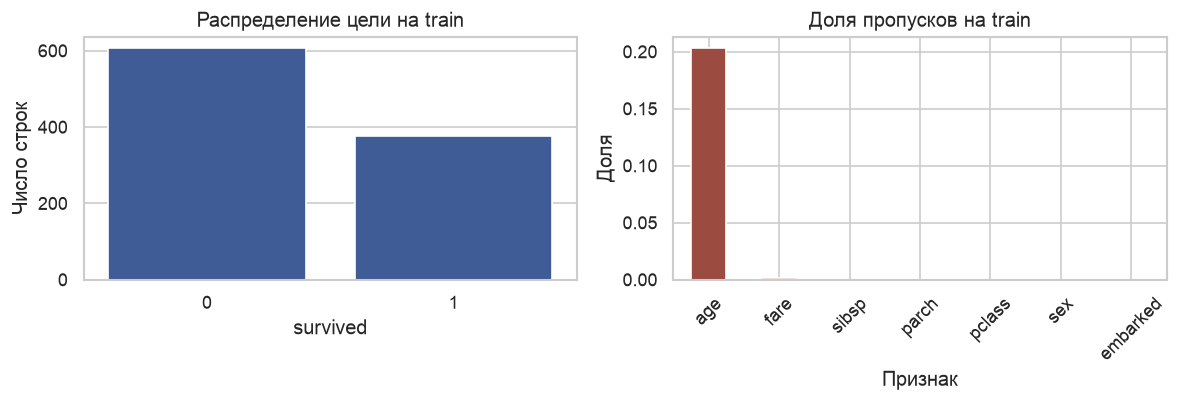

,share
survived,
0,0.617737
1,0.382263


In [5]:
audit_missing = (
    train_data[honest_features].isna().mean().sort_values(ascending=False).rename("missing_rate")
)
target_balance = (
    y_train.value_counts(normalize=True).sort_index().rename("share")
)
display(
    pd.concat(
        [
            train_data[honest_features].dtypes.rename("dtype"),
            train_data[honest_features].isna().sum().rename("missing"),
        ],
        axis=1,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.countplot(x=y_train, ax=axes[0], color="#3157a4")
axes[0].set(title="Распределение цели на train", xlabel="survived", ylabel="Число строк")
audit_missing.plot.bar(ax=axes[1], color="#9b4b3f")
axes[1].set(title="Доля пропусков на train", xlabel="Признак", ylabel="Доля")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
display_figure(fig)
display(target_balance.to_frame())


График цели проверяет, что задача бинарная и классы на train несбалансированы: поэтому одной accuracy недостаточно. График пропусков показывает, какие столбцы потребуют импутации внутри конвейера. Эти описательные результаты не оценивают перенос на новые данные, потому что test остаётся закрытым. Мы проверили обучающий источник и теперь можем построить предобработку внутри каждого fold.


Вывод подтверждает размеры двух непересекающихся частей. До финального этапа используются только `X_train` и `y_train`; `X_test` и `y_test` остаются закрытыми. Чтобы сравнивать алгоритмы без утечки из пропусков и категорий, далее каждое обучение будет включать собственную предобработку внутри fold.


In [6]:
def build_honest_pipeline(estimator) -> Pipeline:
    numeric_steps = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_steps = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    preprocessing = ColumnTransformer(
        [
            ("numeric", numeric_steps, honest_numeric),
            ("categorical", categorical_steps, honest_categorical),
        ]
    )
    return Pipeline([("preprocess", preprocessing), ("model", estimator)])


logistic_model = build_honest_pipeline(
    LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE)
)
tree_model = build_honest_pipeline(
    DecisionTreeClassifier(
        max_depth=4, min_samples_leaf=10, random_state=RANDOM_STATE
    )
)


Числовая ветвь заменяет пропуски медианой, добавляет бинарные индикаторы пропусков и масштабирует получившиеся столбцы; это сохраняет для модели сам факт отсутствия значения. Категориальная ветвь создаёт отдельную метку пропуска и one-hot столбцы, а `handle_unknown="ignore"` позволяет преобразовать редкую категорию, которой не было в конкретном train-fold. Итоговая матрица имеет `n` строк и число столбцов, зависящее от категорий train-fold; преобразователи обучаются только внутри него.

Перед основными моделями нужен ориентир без полезного сигнала. Поэтому следующим шагом добавляем `DummyClassifier`, который всегда предсказывает самый частый класс и показывает, превосходят ли модели тривиальную стратегию.


## 3. Baseline и одинаковый внутренний экзамен

`DummyClassifier(strategy="most_frequent")` — простой baseline: он игнорирует признаки и всегда выбирает самый частый класс train-fold. Пять стратифицированных частей создаются один раз. Baseline, логистическая регрессия и неглубокое дерево получают одинаковые fold, а внешний test не передаётся ни в одну функцию. Считаем среднее и стандартное отклонение accuracy, precision, recall и F1.


In [7]:
# Одинаковые части выборки делают сравнение кандидатов сопоставимым.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
}
cv_rows = []
baseline_model = build_honest_pipeline(DummyClassifier(strategy="most_frequent"))

models_for_cv = {
    "most_frequent_baseline": baseline_model,
    "logistic": logistic_model,
    "shallow_tree": tree_model,
}
for model_name, model in models_for_cv.items():
    result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    for metric in scoring:
        values = result[f"test_{metric}"]
        cv_rows.append(
            {
                "model": model_name,
                "metric": metric,
                "mean": values.mean(),
                "std": values.std(),
            }
        )

cv_summary = pd.DataFrame(cv_rows)
display(cv_summary.pivot(index="model", columns="metric", values="mean").round(3))
display(cv_summary.query("metric == 'f1'").round(3))


metric,accuracy,f1,precision,recall
model,,,,
logistic,0.766,0.678,0.715,0.645
most_frequent_baseline,0.618,0.000,0.000,0.000
shallow_tree,0.783,0.690,0.751,0.643


,model,metric,mean,std
3,most_frequent_baseline,f1,0.000,0.000
7,logistic,f1,0.678,0.014
11,shallow_tree,f1,0.690,0.070


Таблица позволяет сравнить каждую модель с baseline на тех же наблюдениях. У baseline precision и recall положительного класса могут быть нулевыми даже при внешне приемлемой accuracy: он не находит выживших и потому непригоден при цене ложноотрицательных ошибок. Разброс по пяти fold показывает лишь чувствительность к этому разбиению train, а не неопределённость внешнего test. Получив честный ориентир, разберём метрики через конкретные TP, FP и FN.


## 4. Цена ошибок

Для положительного класса `survived = 1`:

- **FN** — выживший, которого модель не отметила; он снижает recall, поэтому ограничение `recall ≥ 0.85` задаёт верхнюю цену пропуска положительного случая;
- **FP** — невыживший, которого модель отметила; он снижает precision и увеличивает нагрузку `flag_rate`, поэтому ограничение `flag_rate ≤ 0.55` не позволяет отметить почти всех;
- $precision=TP/(TP+FP)$ — какая доля флагов действительно положительна;
- $recall=TP/(TP+FN)$ — какую долю положительных нашли;
- $F1=2\cdot precision\cdot recall/(precision+recall)$ — гармонический баланс без явного ограничения нагрузки.

**Упражнение.** Получите OOF-классы логистической модели при пороге 0,5, разложите матрицу ошибок и вычислите три метрики вручную.


In [8]:
oof_logistic_classes = cross_val_predict(
    logistic_model, X_train, y_train, cv=cv, method="predict", n_jobs=1
)
# Для меток [0, 1] ravel() возвращает ячейки в порядке TN, FP, FN, TP.
tn, fp, fn, tp = confusion_matrix(y_train, oof_logistic_classes).ravel()

# BEGIN SOLUTION
precision_manual = tp / (tp + fp)
recall_manual = tp / (tp + fn)
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)
# END SOLUTION

manual_metrics = pd.Series(
    {"precision": precision_manual, "recall": recall_manual, "f1": f1_manual}
)
display(manual_metrics.round(3).to_frame("manual"))


,manual
precision,0.714
recall,0.645
f1,0.678


Ручные значения связывают агрегированные метрики с конкретными типами ошибок OOF. Они получены для порога 0,5 и ещё не реализуют операционное правило: изменение порога одновременно меняет FN, FP и долю флагов. Поэтому далее нужны OOF-вероятности, на которых можно выбрать порог, не открывая test.


## 5. Порог по OOF-вероятностям обучающей выборки

Логистическая регрессия и неглубокое дерево остаются центральными моделями сравнения. Бюро также передаёт фиксированный **третий кандидат для порогового испытания** — небольшой случайный лес с теми же корректными признаками. Его конфигурация задана заранее: это не новый поиск гиперпараметров и не упражнение по настройке.

До выбора кандидата проверим всех троих по одному правилу и одними и теми же частями выборки: `recall ≥ 0.85`, `flag_rate ≤ 0.55`, затем максимум precision. `cross_val_predict(..., method="predict_proba")` даёт каждой строке обучающей выборки вероятность от модели, которая эту строку не видела. Внешняя тестовая выборка по-прежнему закрыта.

Параметры леса фиксируют сложность заранее: 300 деревьев уменьшают случайный разброс ансамбля; `min_samples_leaf=5` сглаживает слишком локальные правила; `max_features=0.8` декоррелирует деревья; `class_weight="balanced"` увеличивает вклад более редкого класса. Это обоснование конфигурации, а не её подбор по holdout.


In [9]:
supplied_random_forest = build_honest_pipeline(
    RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        max_features=0.8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
)

candidate_models = {
    "logistic": logistic_model,
    "shallow_tree": tree_model,
    "supplied_random_forest": supplied_random_forest,
}
candidate_order = list(candidate_models)
threshold_grid = np.linspace(0.05, 0.95, 181)

def scan_thresholds(probabilities: np.ndarray) -> pd.DataFrame:
    rows = []
    for threshold in threshold_grid:
        predictions = (probabilities >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "precision": precision_score(y_train, predictions, zero_division=0),
                "recall": recall_score(y_train, predictions),
                "f1": f1_score(y_train, predictions),
                "flag_rate": predictions.mean(),
            }
        )
    return pd.DataFrame(rows)

candidate_oof_probabilities = {}
candidate_threshold_tables = {}
feasibility_rows = []

# cross_val_predict создаёт OOF-вероятность для каждой строки X_train.
for candidate_name, candidate_model in candidate_models.items():
    probabilities = cross_val_predict(
        candidate_model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]
    table = scan_thresholds(probabilities)
    feasible_rows = table.query("recall >= 0.85 and flag_rate <= 0.55").copy()
    rows_under_cap = table.query("flag_rate <= 0.55")
    best_feasible = (
        feasible_rows.sort_values(
            ["precision", "threshold"], ascending=[False, False]
        ).iloc[0]
        if not feasible_rows.empty
        else None
    )

    candidate_oof_probabilities[candidate_name] = probabilities
    candidate_threshold_tables[candidate_name] = table
    feasibility_rows.append(
        {
            "candidate": candidate_name,
            "rule_feasible": not feasible_rows.empty,
            "max_recall_at_flag_cap": rows_under_cap["recall"].max(),
            "best_precision_if_feasible": (
                best_feasible["precision"] if best_feasible is not None else np.nan
            ),
            "best_threshold_if_feasible": (
                best_feasible["threshold"] if best_feasible is not None else np.nan
            ),
        }
    )

candidate_feasibility = pd.DataFrame(feasibility_rows)
display(candidate_feasibility.round(3))

feasibility_by_candidate = candidate_feasibility.set_index("candidate")[
    "rule_feasible"
].astype(bool)
expected_feasibility = {
    "logistic": False,
    "shallow_tree": False,
    "supplied_random_forest": True,
}
if feasibility_by_candidate.to_dict() != expected_feasibility:
    raise RuntimeError("Фиксированные кандидаты больше не воспроизводят решение аудита")

selected_candidate_name = "supplied_random_forest"
threshold_model = candidate_models[selected_candidate_name]
oof_probabilities = candidate_oof_probabilities[selected_candidate_name]
print(
    "Выбран кандидат:", selected_candidate_name,
    "— только он выполняет операционное правило на OOF train."
)


,candidate,rule_feasible,max_recall_at_flag_cap,best_precision_if_feasible,best_threshold_if_feasible
0,logistic,False,0.829,NaN,NaN
1,shallow_tree,False,0.835,NaN,NaN
2,supplied_random_forest,True,0.851,0.601,0.3


Выбран кандидат: supplied_random_forest — только он выполняет операционное правило на OOF train.


Таблица проверяет выполнимость одного и того же правила для каждого кандидата на OOF train. OOF означает, что вероятность каждой строки получена моделью, обученной на остальных fold; длина каждого массива равна длине `X_train`. Зафиксированный лес выбирается только потому, что выполняет заранее записанные ограничения, а не из-за результата внешнего test. Теперь к его OOF-вероятностям можно применить однозначный порядок выбора порога.


### Упражнение: применяем правило без переговоров с тестовой выборкой

Переберите пороги от 0,05 до 0,95. Для каждого посчитайте precision, recall, F1 и `flag_rate`. Оставьте `recall ≥ 0.85` и `flag_rate ≤ 0.55`, затем максимизируйте precision; при равенстве выбирайте более высокий порог.

Если допустимых строк нет, корректный результат — остановиться и сообщить конфликт, а не тайно ослабить критерий.


In [10]:
threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 181):
    candidate_predictions = (oof_probabilities >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_train, candidate_predictions, zero_division=0),
            "recall": recall_score(y_train, candidate_predictions),
            "f1": f1_score(y_train, candidate_predictions),
            "flag_rate": candidate_predictions.mean(),
        }
    )
threshold_table = pd.DataFrame(threshold_rows)

# BEGIN SOLUTION
# Ограничения и порядок выбора применяем только к OOF-прогнозам обучающей выборки.
feasible = threshold_table.query("recall >= 0.85 and flag_rate <= 0.55").copy()
if feasible.empty:
    raise RuntimeError("Операционное правило несовместимо с моделью на OOF train")
selected_row = feasible.sort_values(
    ["precision", "threshold"], ascending=[False, False]
).iloc[0]
selected_threshold = float(selected_row["threshold"])
# END SOLUTION

display(feasible.sort_values("precision", ascending=False).head().round(3))
print(f"Зафиксированный порог: {selected_threshold:.3f}")


,threshold,precision,recall,f1,flag_rate
50,0.3,0.601,0.851,0.704,0.541


Зафиксированный порог: 0.300


Первые строки таблицы — допустимые пороги OOF train, отсортированные по precision; при равенстве выбирается более высокий порог. Такой выбор использует каждую train-строку как валидационную ровно в её fold, но всё равно адаптирует порог к этой обучающей выборке. Поэтому выбранное значение фиксируется сейчас, а его перенос проверяется позднее единственным holdout-измерением.


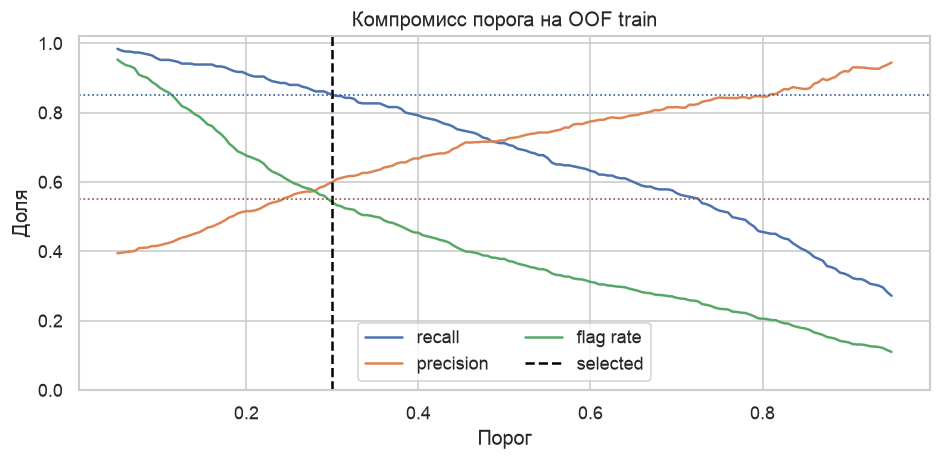

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_table["threshold"], threshold_table["recall"], label="recall")
ax.plot(threshold_table["threshold"], threshold_table["precision"], label="precision")
ax.plot(threshold_table["threshold"], threshold_table["flag_rate"], label="flag rate")
ax.axvline(selected_threshold, color="black", linestyle="--", label="selected")
ax.axhline(0.85, color="#3157a4", linestyle=":", linewidth=1)
ax.axhline(0.55, color="#9b4b3f", linestyle=":", linewidth=1)
ax.set(xlabel="Порог", ylabel="Доля", ylim=(0, 1.02), title="Компромисс порога на OOF train")
ax.legend(ncol=2)
plt.tight_layout()
display_figure(fig)


Кривые визуализируют цену повышения порога: доля флагов и recall обычно уменьшаются, а precision может расти. Вертикальная линия отмечает решение, принятое по OOF train; горизонтальные линии показывают ограничения, но не гарантируют их выполнение на holdout. После этой точки запрещено менять модель или порог по результатам test.


## 6. Оцениваем модель на внешней тестовой выборке один раз

Конфигурация модели и порог уже записаны. Теперь обучаемся на всей обучающей выборке, получаем вероятности тестовой и сравниваем пороги 0,5 и выбранный. Если тестовая выборка не выполняет ограничение, это результат проверки, а не повод вернуться и подобрать порог по тестовой выборке.


In [12]:
holdout_evaluations = 0
# Модель и порог уже зафиксированы; тестовая выборка используется ровно для одной оценки.
threshold_model.fit(X_train, y_train)
test_probabilities = threshold_model.predict_proba(X_test)[:, 1]
holdout_evaluations += 1

def classification_metrics(y_true: pd.Series, probabilities: np.ndarray, threshold: float) -> dict:
    predictions = (probabilities >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions),
        "flag_rate": predictions.mean(),
    }

test_comparison = pd.DataFrame(
    [
        classification_metrics(y_test, test_probabilities, 0.5),
        classification_metrics(y_test, test_probabilities, selected_threshold),
    ],
    index=["default_0.5", "oof_selected"],
)
display(test_comparison.round(3))
final_predictions = (test_probabilities >= selected_threshold).astype(int)


,threshold,accuracy,precision,recall,f1,flag_rate
default_0.5,0.5,0.823,0.752,0.80,0.775,0.405
oof_selected,0.3,0.735,0.599,0.92,0.726,0.585


Две строки используют один и тот же единожды открытый holdout и сравнивают заранее определённые правила: стандартный порог 0,5 и OOF-порог. Строка `oof_selected` — финальная оценка выбранной процедуры; расхождение с OOF ожидаемо из-за конечного размера и переноса. Даже если ограничение на test нарушено, возвращаться к подбору нельзя: тогда holdout перестанет быть независимым.


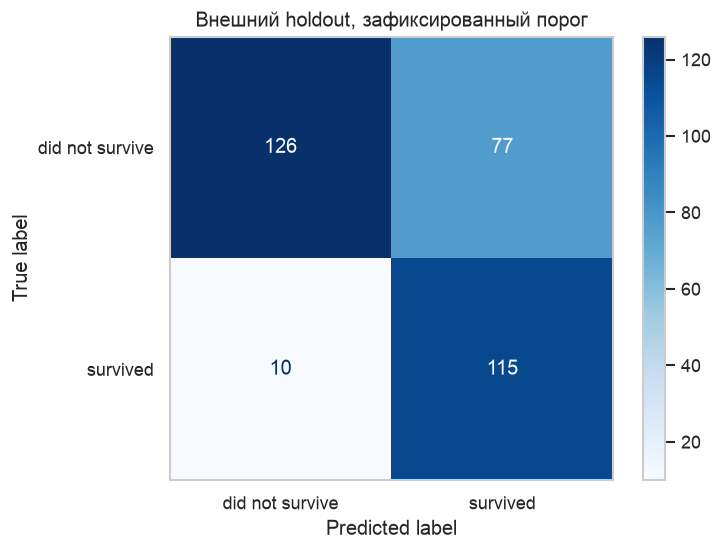

In [13]:
confusion_display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["did not survive", "survived"],
    cmap="Blues",
)
plt.title("Внешний holdout, зафиксированный порог")
plt.grid(False)
display_figure(confusion_display.figure_)


Матрица показывает абсолютные количества TN, FP, FN и TP за финальными долями. В этой постановке FN соответствуют пропущенным положительным случаям, а FP — лишним флагам; их нельзя считать взаимозаменяемыми без предметно заданной стоимости. Один holdout даёт одну реализацию этих ошибок, поэтому следующий этап проверяет, не скрывает ли агрегирование особенно малые или отличающиеся группы.


## 7. Срезы: где скрылась цена

Одна агрегированная метрика усредняет разные группы. Для каждого сочетания пола и класса покажем размер, precision, recall, false-positive rate и количество ошибок. Малые группы отмечаем размером — нестабильная доля без `n` легко вводит в заблуждение.

**Упражнение:** реализуйте функцию одного среза через матрицу ошибок.


In [14]:
def slice_metrics(group: pd.DataFrame) -> pd.Series:
    # BEGIN SOLUTION
    # Показываем размер каждой группы, потому что метрики на малых группах нестабильны.
    y_true = group["actual"].to_numpy()
    y_pred = group["predicted"].to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    # zero_division=0 возвращает 0, если знаменатель метрики в маленькой группе равен нулю.
    return pd.Series(
        {
            "n": len(group),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "fpr": fp / (fp + tn) if fp + tn else np.nan,
            "errors": fp + fn,
        }
    )
    # END SOLUTION

slice_frame = test_data[["sex", "pclass"]].copy()
slice_frame["actual"] = y_test
slice_frame["predicted"] = final_predictions
slice_report = slice_frame.groupby(["sex", "pclass"], dropna=False).apply(
    slice_metrics, include_groups=False
)
display(slice_report.round(3))


n  precision  recall    fpr  errors
sex    pclass                                         
female 1        40.0      0.950   1.000  1.000     2.0
       2        28.0      1.000   1.000    NaN     0.0
       3        53.0      0.522   1.000  0.759    22.0
male   1        43.0      0.406   0.812  0.704    22.0
       2        42.0      0.500   0.800  0.108     5.0
       3       122.0      0.211   0.571  0.278    36.0

Таблица срезов всегда читает метрику вместе с `n` и числом ошибок: одинаковая доля на маленькой группе меняется сильнее от одной строки. Различия precision, recall или FPR описывают поведение зафиксированной модели на этом holdout, но не доказывают причинное влияние пола или класса. Мы получили диагностические срезы; для вывода нужно явно отделить наблюдение, неопределённость и рекомендуемое действие.


### Ассоциация не равна причине

Пол, класс билета и возраст связаны с историческим исходом в этой таблице. Модель не отвечает на вопросы «что случилось бы, если изменить признак?» и «какая стратегия спасения вызовет лучший исход?». Для причинного вывода нужны дизайн исследования, явные вмешательства и дополнительные предположения.

> **Типичная ошибка:** многократно открывать test после каждой правки порога. Тогда порог адаптируется к тестовой выборке, и итоговая оценка становится оптимистичной.

**Дополнительное исследование:** постройте бутстреп-интервалы для recall каждого среза и сравните ширину с размером группы.


## 8. Аудиторская записка

Отразите конфликт между агрегированной долей правильных ответов и операционными требованиями. Отдельно укажите, какие различия видны по срезам, но не превращайте их в причинные утверждения.


In [15]:
selected_test = test_comparison.loc["oof_selected"]
# BEGIN SOLUTION
audit_memo = {
    "established_fact": (
        f"Порог {selected_threshold:.3f}, выбранный только по OOF train, дал на внешнем "
        f"test recall={selected_test['recall']:.3f}, precision={selected_test['precision']:.3f} "
        f"и flag_rate={selected_test['flag_rate']:.3f}."
    ),
    "supported_interpretation": (
        "Accuracy не описывает цену FN и FP; выполнение ограничения на train не "
        "гарантирует операционную нагрузку на новых данных."
    ),
    "not_proven": (
        "Различия срезов не доказывают причинное влияние пола или класса и не задают "
        "правильную политику эвакуации."
    ),
    "limitations": (
        "Набор исторический, группы местами малы, а правило тревоги учебное; интервалы "
        "неопределённости для срезов здесь не рассчитаны."
    ),
    "recommended_action": (
        "Зафиксировать цену ошибок до обучения, хранить внешний test закрытым и провести "
        "предметную проверку порога и нагрузки на независимых современных данных."
    ),
}
# END SOLUTION
display(pd.Series(audit_memo, name="Записка II-03").to_frame())


,Записка II-03
established_fact,"Порог 0.300, выбранный только по OOF train, да..."
supported_interpretation,Accuracy не описывает цену FN и FP; выполнение...
not_proven,Различия срезов не доказывают причинное влияни...
limitations,"Набор исторический, группы местами малы, а пра..."
recommended_action,"Зафиксировать цену ошибок до обучения, хранить..."


Записка связывает финальные метрики с процедурой их получения и отдельно фиксирует ограничения. Она не превращает test в новый этап настройки и не выдаёт срезы за причинный эффект. На этом учебный аудит завершён: повторная оценка потребовала бы новой независимой выборки, а не ещё одного просмотра текущего holdout.


**Вывод расследования.** Порог можно корректно выбрать по обучающей выборке и всё равно получить другую долю флагов на тестовой выборке. Это не повод подбирать его заново по тестовой выборке: это важное свидетельство неопределённости переноса. Исторические срезы требуют внимания, но сами не устанавливают причину.


In [16]:
expected_candidate_order = [
    "logistic",
    "shallow_tree",
    "supplied_random_forest",
]
candidate_feasibility_flags = feasibility_by_candidate.to_dict()
rf_parameters = threshold_model.get_params()
checks = {
    "checksum_verified": actual_sha256 == DATASET_SHA256,
    "split_disjoint": set(train_index).isdisjoint(test_index),
    "no_post_outcome_features": {"boat", "body"}.isdisjoint(honest_features),
    "oof_matches_train": all(
        len(values) == len(y_train) for values in candidate_oof_probabilities.values()
    ),
    "candidate_order_fixed": candidate_order == expected_candidate_order,
    "simple_candidates_infeasible": (
        not candidate_feasibility_flags["logistic"]
        and not candidate_feasibility_flags["shallow_tree"]
    ),
    "supplied_rf_feasible": candidate_feasibility_flags["supplied_random_forest"],
    "rf_selected_for_feasibility": selected_candidate_name == "supplied_random_forest",
    "rf_configuration_fixed": (
        rf_parameters["model__n_estimators"] == 300
        and rf_parameters["model__min_samples_leaf"] == 5
        and rf_parameters["model__max_features"] == 0.8
        and rf_parameters["model__random_state"] == RANDOM_STATE
        and rf_parameters["model__n_jobs"] == 1
    ),
    "feasible_threshold_found": not feasible.empty,
    "outer_test_opened_once": holdout_evaluations == 1,
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())
assert candidate_feasibility_flags == expected_feasibility
assert selected_row["recall"] >= 0.85
assert selected_row["flag_rate"] <= 0.55
rf_feasibility_row = candidate_feasibility.set_index("candidate").loc[
    "supplied_random_forest"
]
assert np.isclose(
    selected_threshold, rf_feasibility_row["best_threshold_if_feasible"]
)
assert np.isclose(precision_manual, precision_score(y_train, oof_logistic_classes))
assert np.isclose(recall_manual, recall_score(y_train, oof_logistic_classes))
assert np.isclose(f1_manual, f1_score(y_train, oof_logistic_classes))


,passed
checksum_verified,True
split_disjoint,True
no_post_outcome_features,True
oof_matches_train,True
candidate_order_fixed,True
simple_candidates_infeasible,True
supplied_rf_feasible,True
rf_selected_for_feasibility,True
rf_configuration_fixed,True
feasible_threshold_found,True


## Расследование закрыто

Перезапустите ядро и выполните **Run All**. Проверьте протокол по `check_result.md`: одинаковые части кросс-валидации, OOF только для обучающей выборки, одна внешняя тестовая выборка, срезы с размером группы и пятичастная записка. Следующее расследование перенесёт те же вопросы в регрессию и географическое обобщение.
